In [ ]:
import numpy as np
import pandas as pd
import pandas_datareader as dr
import requests

#define URL
sp500_url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies '
header = {
    "User-Agent": "Mozilla/5.0 (x11; Linux x86_64) AppleWebKit/537.36 (KHTML, like  Gecko) Chrome/50.2661.75 Safari/537.36",
}
r = requests.get(sp500_url, headers=header)

# Get all tables from the Wikipedia page
tables = pd.read_html(r.text)

# Iterate through the tables to find the one with 'Symbol' column
data_table = None
for table in tables:
    if 'Symbol' in table.columns:
        data_table = table
        break

if data_table is None:
    print("Could not find a table with a 'Symbol' column.")
else:
    print("Found table with 'Symbol' column.")
    # display the first few rows of the table to confirm
    display(data_table.head())

/tmp/ipython-input-3567808445.py:14: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(r.text)


Found table with 'Symbol' column.


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [ ]:
data_table

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989
...,...,...,...,...,...,...,...,...
498,XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,"White Plains, New York",2011-11-01,1524472,2011
499,YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,1041061,1997
500,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,877212,1969
501,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,1136869,1927


In [ ]:
data_table["Symbol"]

,Symbol
0,MMM
1,AOS
2,ABT
3,ABBV
4,ACN
...,...
498,XYL
499,YUM
500,ZBRA
501,ZBH


In [ ]:
import yfinance as yf
!pip install yahoofinancials
from yahoofinancials import YahooFinancials
from datetime import datetime
#Define a start date and end date
start = '2022-01-01'
end = '2025-01-01'
##Read Stock price Data (EG Apple stock price)
Data_stock_price = yf.download(data_table['Symbol'].values.tolist(), start= start, end= end)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for yahoofinancials: filename=yahoofinancials-1.20-py3-none-any.whl size=38618 sha256=5a5a88c0272c99cad4f00b8cc07f765f95b4b137ed4308417606d4245d9d2b27
  Stored in directory: /root/.cache/pip/wheels/b0/e1/ca/e683b02e57db550881c8ebb89ba3eccb7a5c0ebfad7f03acea
Successfully built yahoofinancials


/tmp/ipython-input-2700750907.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  Data_stock_price = yf.download(data_table['Symbol'].values.tolist(), start= start, end= end)
[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
4 Failed downloads:
ERROR:yfinance:['BF.B']: YFPricesMissingError('possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01)')
ERROR:yfinance:['SOLS', 'Q']: YFPricesMissingError('possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1641013200, endDate = 1735707600")')
ERROR:yfinance:['BRK.B']: YFTzMissingError('possibly delisted; no timezone found')


In [ ]:
import yfinance as yf
import pandas as pd
import requests

# 1. Get S&P 500 tickers from Wikipedia
# -----------------------------
sp500_url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
header = {"User-Agent": "Mozilla/5.0"}
r = requests.get(sp500_url, headers=header)

tables = pd.read_html(r.text)
data_table = None
for table in tables:
    if 'Symbol' in table.columns:
        data_table = table
        break

# 2. Fix ticker symbols for Yahoo Finance
# -----------------------------
tickers = data_table["Symbol"].str.replace(".", "-", regex=False).tolist()

# Remove invalid/delisted tickers
invalid_tickers = ['SOLS', 'Q']
tickers = [t for t in tickers if t not in invalid_tickers]

# 3. Download stock price data
# -----------------------------
start = '2022-01-01'
end = '2025-01-01'

Data_stock_price = yf.download(tickers, start=start, end=end)

# 4. Check downloaded data
# -----------------------------
print("Downloaded stock data for", len(Data_stock_price.columns.levels[1]), "tickers")
Data_stock_price.head()


/tmp/ipython-input-3336269438.py:11: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(r.text)
/tmp/ipython-input-3336269438.py:31: FutureWarning: YF.download() has changed argument auto_adjust default to True
  Data_stock_price = yf.download(tickers, start=start, end=end)
[*********************100%***********************]  501 of 501 completed


Downloaded stock data for 501 tickers


Price            Close                                                  \
Ticker               A        AAPL        ABBV        ABNB         ABT   
Date                                                                     
2022-01-03  152.320068  178.270309  116.779289  172.679993  128.996094   
2022-01-04  147.170670  176.007797  116.555069  170.800003  125.962372   
2022-01-05  144.649582  171.325974  117.167358  162.250000  125.396431   
2022-01-06  145.155701  168.466003  116.615448  159.750000  125.377838   
2022-01-07  141.291260  168.632492  116.313644  166.050003  125.767540   

Price                                                                 ...  \
Ticker           ACGL         ACN        ADBE         ADI        ADM  ...   
Date                                                                  ...   
2022-01-03  42.362530  383.711945  564.369995  165.624527  60.489796  ...   
2022-01-04  42.914051  380.969818  554.000000  164.128647  61.612438  ...   
2022-01-05  42.410072  374.260742  514.429993  161.594955  61.131302  ...   
2022-01-06  42.657307  356.187500  514.119995  162.109177  61.674812  ...   
2022-01-07  42.856995  349.355804  510.700012  157.855179  62.200500  ...   

Price        Volume                                                          \
Ticker           WY     WYNN      XEL       XOM      XYL       XYZ      YUM   
Date                                                                          
2022-01-03  3831100  2437800  3501100  24282400   759100   7315700  1251400   
2022-01-04  3089700  2292300  4197000  38584000   925400  14768500   935900   
2022-01-05  3737600  3439900  4166000  34033300  1090200  17546200   977900   
2022-01-06  3315200  2583200  2296000  30668500   703400  16244200   862400   
2022-01-07  3309900  1720400  2673100  23985400   765000   9426000   833700   

Price                                 
Ticker          ZBH    ZBRA      ZTS  
Date                                  
2022-01-03  1184809  272600  2772700  
2022-01-04  1400800  346000  4664000  
2022-01-05  1895715  403700  4749400  
2022-01-06  1088813  338300  3103400  
2022-01-07  1690230  432800  2206500  

[5 rows x 2505 columns]

In [ ]:
Data_stock_price_clean = Data_stock_price.dropna(axis=1, how='all')
Data_stock_price_clean = Data_stock_price_clean.fillna(method='ffill')
Data_stock_price_clean.head()

/tmp/ipython-input-372568854.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  Data_stock_price_clean = Data_stock_price_clean.fillna(method='ffill')


Price            Close                                                  \
Ticker               A        AAPL        ABBV        ABNB         ABT   
Date                                                                     
2022-01-03  152.320068  178.270309  116.779289  172.679993  128.996094   
2022-01-04  147.170670  176.007797  116.555069  170.800003  125.962372   
2022-01-05  144.649582  171.325974  117.167358  162.250000  125.396431   
2022-01-06  145.155701  168.466003  116.615448  159.750000  125.377838   
2022-01-07  141.291260  168.632492  116.313644  166.050003  125.767540   

Price                                                                 ...  \
Ticker           ACGL         ACN        ADBE         ADI        ADM  ...   
Date                                                                  ...   
2022-01-03  42.362530  383.711945  564.369995  165.624527  60.489796  ...   
2022-01-04  42.914051  380.969818  554.000000  164.128647  61.612438  ...   
2022-01-05  42.410072  374.260742  514.429993  161.594955  61.131302  ...   
2022-01-06  42.657307  356.187500  514.119995  162.109177  61.674812  ...   
2022-01-07  42.856995  349.355804  510.700012  157.855179  62.200500  ...   

Price        Volume                                                          \
Ticker           WY     WYNN      XEL       XOM      XYL       XYZ      YUM   
Date                                                                          
2022-01-03  3831100  2437800  3501100  24282400   759100   7315700  1251400   
2022-01-04  3089700  2292300  4197000  38584000   925400  14768500   935900   
2022-01-05  3737600  3439900  4166000  34033300  1090200  17546200   977900   
2022-01-06  3315200  2583200  2296000  30668500   703400  16244200   862400   
2022-01-07  3309900  1720400  2673100  23985400   765000   9426000   833700   

Price                                 
Ticker          ZBH    ZBRA      ZTS  
Date                                  
2022-01-03  1184809  272600  2772700  
2022-01-04  1400800  346000  4664000  
2022-01-05  1895715  403700  4749400  
2022-01-06  1088813  338300  3103400  
2022-01-07  1690230  432800  2206500  

[5 rows x 2505 columns]

In [ ]:
import math
daily_returns = Data_stock_price_clean['Close'].pct_change().dropna()
annual_volatility = daily_returns.std() * math.sqrt(252)
daily_returns.head(), annual_volatility.head()


(Ticker             A      AAPL      ABBV      ABNB       ABT      ACGL  \
 Date                                                                     
 2024-03-28 -0.012622 -0.010559  0.009703 -0.008713  0.001586  0.010494   
 2024-04-01  0.001969 -0.008456 -0.007359 -0.009639 -0.013813 -0.001406   
 2024-04-02 -0.009550 -0.006999 -0.000387 -0.019955 -0.000624 -0.008883   
 2024-04-03 -0.003052  0.004798 -0.018596 -0.004809 -0.006606  0.008088   
 2024-04-04 -0.016628 -0.004893 -0.053178 -0.003138 -0.010514 -0.012361   
 
 Ticker           ACN      ADBE       ADI       ADM  ...        WY      WYNN  \
 Date                                                ...                       
 2024-03-28  0.016630  0.000397  0.023069 -0.002858  ... -0.000556  0.004323   
 2024-04-01 -0.021465 -0.004974 -0.005915 -0.007324  ... -0.009747  0.042355   
 2024-04-02 -0.007990 -0.005736 -0.008849  0.005613  ... -0.003656 -0.012200   
 2024-04-03 -0.012424 -0.004407  0.002463 -0.000798  ... -0.013830  0.011

In [ ]:
import yfinance as yf
import pandas as pd

# --- 2b. Beta Calculation ---

def calculate_betas(market_ticker, stock_list, start_date, end_date):
    # Download market data
    market = yf.download(market_ticker, start=start_date, end=end_date)
    market['daily_return'] = market['Close'].pct_change()
    market.dropna(inplace=True)
    market_std = market['daily_return'].std()

    betas_list = []

    # Loop through each stock
    for stock in stock_list:
        data = yf.download(stock, start=start_date, end=end_date)
        data['daily_return'] = data['Close'].pct_change()
        data.dropna(inplace=True)

        # Correlation with market
        corr = data['daily_return'].corr(market['daily_return'])
        # Beta formula
        beta_val = corr * (data['daily_return'].std() / market_std)
        betas_list.append(beta_val)

    # Create a DataFrame for results
    beta_df = pd.DataFrame({
        'Stock_Name': stock_list,
        'Beta': betas_list
    })

    return beta_df

# Call the function for all S&P 500 stocks vs S&P 500 index (^GSPC)
betas_df = calculate_betas('^GSPC', data_table['Symbol'].values.tolist(), '2022-01-01', '2025-01-01')

# Quick check
betas_df.head()


/tmp/ipython-input-4010054396.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market = yf.download(market_ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-4010054396.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-4010054396.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-4010054396.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-in

,Stock_Name,Beta
0,MMM,0.783736
1,AOS,0.924451
2,ABT,0.672317
3,ABBV,0.299098
4,ACN,1.094207


In [ ]:
import math
daily_returns = Data_stock_price['Close'].pct_change()
annual_volatility = daily_returns.std() *math.sqrt(252)

In [ ]:
annual_volatility

,0
Ticker,
A,0.296259
AAPL,0.270935
ABBV,0.219958
ABNB,0.467875
ABT,0.217839
...,...
XYZ,0.653825
YUM,0.191335
ZBH,0.245157


/tmp/ipython-input-1395007028.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market = yf.download(market_ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1395007028.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1395007028.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1395007028.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-i

K=2 → Silhouette Score = 0.527802410880822
K=3 → Silhouette Score = 0.5334454251398723
K=4 → Silhouette Score = 0.5156915678216437
K=5 → Silhouette Score = 0.5244583655055848
K=6 → Silhouette Score = 0.5322938368035908
K=7 → Silhouette Score = 0.5043903685381647
K=8 → Silhouette Score = 0.5043670613767519
K=9 → Silhouette Score = 0.5077869129060574


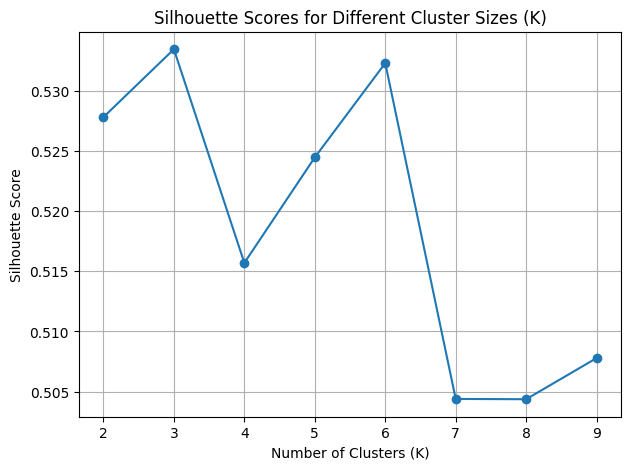

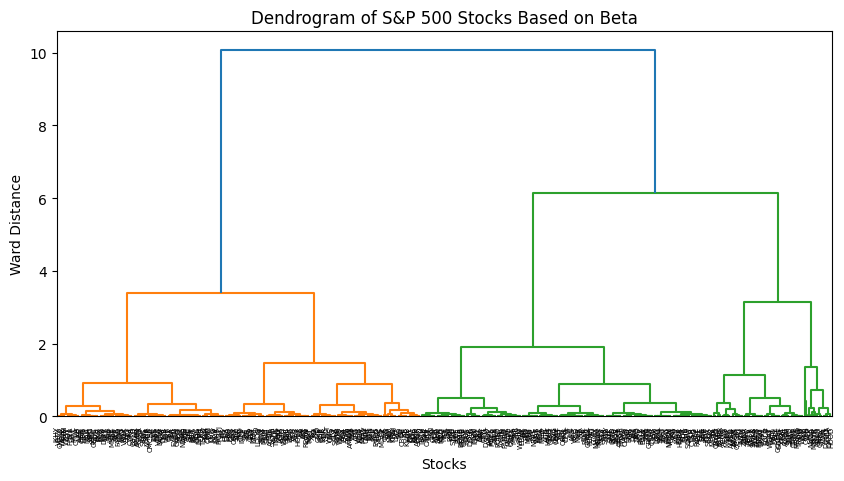

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import yfinance as yf

# Define the calculate_betas function (copied from cell 3sEKGjUZihSW) to ensure betas_df is created
def calculate_betas(market_ticker, stock_list, start_date, end_date):
    # Download market data
    market = yf.download(market_ticker, start=start_date, end=end_date)
    market['daily_return'] = market['Close'].pct_change()
    market.dropna(inplace=True)
    market_std = market['daily_return'].std()

    betas_list = []

    # Loop through each stock
    for stock in stock_list:
        data = yf.download(stock, start=start_date, end=end_date)
        data['daily_return'] = data['Close'].pct_change()
        data.dropna(inplace=True)

        # Correlation with market
        corr = data['daily_return'].corr(market['daily_return'])
        # Beta formula
        beta_val = corr * (data['daily_return'].std() / market_std)
        betas_list.append(beta_val)

    # Create a DataFrame for results
    beta_df = pd.DataFrame({
        'Stock_Name': stock_list,
        'Beta': betas_list
    })

    return beta_df

# Re-create data_table if it's not in the kernel state (although it should be from previous steps)
# This is a safe guard to ensure data_table is available.
if 'data_table' not in locals() and 'data_table' not in globals():
    sp500_url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    header = {"User-Agent": "Mozilla/5.0"}
    r = requests.get(sp500_url, headers=header)
    tables = pd.read_html(r.text)
    for table in tables:
        if 'Symbol' in table.columns:
            data_table = table
            break

# Call the function for all S&P 500 stocks vs S&P 500 index (^GSPC)
betas_df = calculate_betas('^GSPC', data_table['Symbol'].values.tolist(), '2022-01-01', '2025-01-01')

# Clean Beta values
clean_betas_df = betas_df.dropna(subset=['Beta']).copy()
beta_values = clean_betas_df[['Beta']].values

# Range of K values for silhouette
K_values = [2, 3, 4, 5, 6, 7, 8, 9]

silhouette_scores = []

# Calculate silhouette score for each K
for K in K_values:
    model = AgglomerativeClustering(n_clusters=K, linkage='ward')
    labels = model.fit_predict(beta_values)
    score = silhouette_score(beta_values, labels)
    silhouette_scores.append(score)
    print(f"K={K} → Silhouette Score = {score}")

# Plot Silhouette Scores
plt.figure(figsize=(7, 5))
plt.plot(K_values, silhouette_scores, marker='o')
plt.title("Silhouette Scores for Different Cluster Sizes (K)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

# --- Dendrogram ---
linked = linkage(beta_values, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linked,
           orientation='top',
           labels=clean_betas_df['Stock_Name'].values,
           distance_sort='ascending',
           show_leaf_counts=False)  # Set to True if you want leaf counts
plt.title("Dendrogram of S&P 500 Stocks Based on Beta")
plt.xlabel("Stocks")
plt.ylabel("Ward Distance")
plt.show()


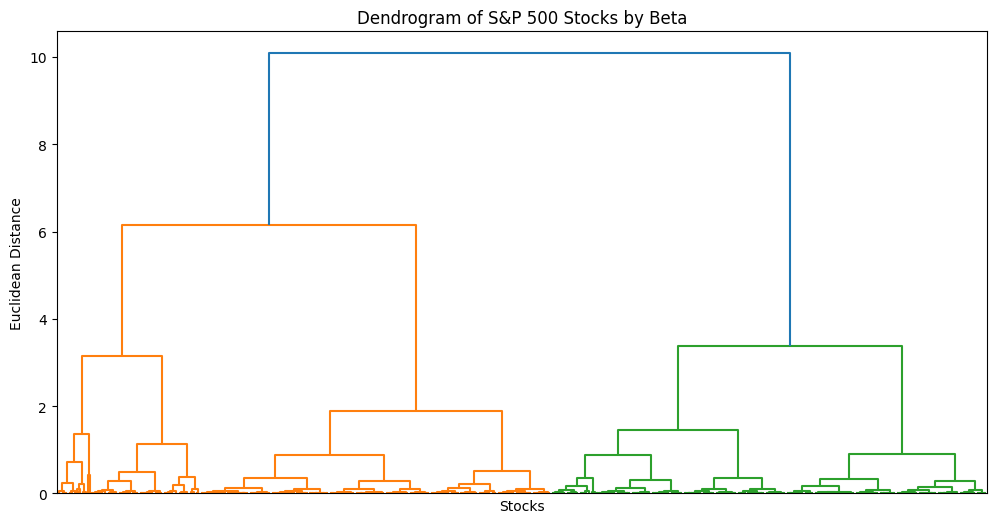

K=2 → Silhouette Score = 0.5278
K=3 → Silhouette Score = 0.5334
K=4 → Silhouette Score = 0.5157
K=5 → Silhouette Score = 0.5245
K=6 → Silhouette Score = 0.5323
K=7 → Silhouette Score = 0.5044
K=8 → Silhouette Score = 0.5044
K=9 → Silhouette Score = 0.5078


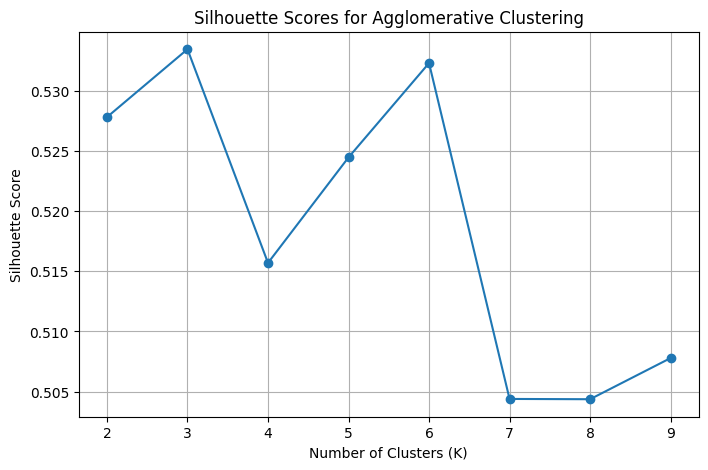

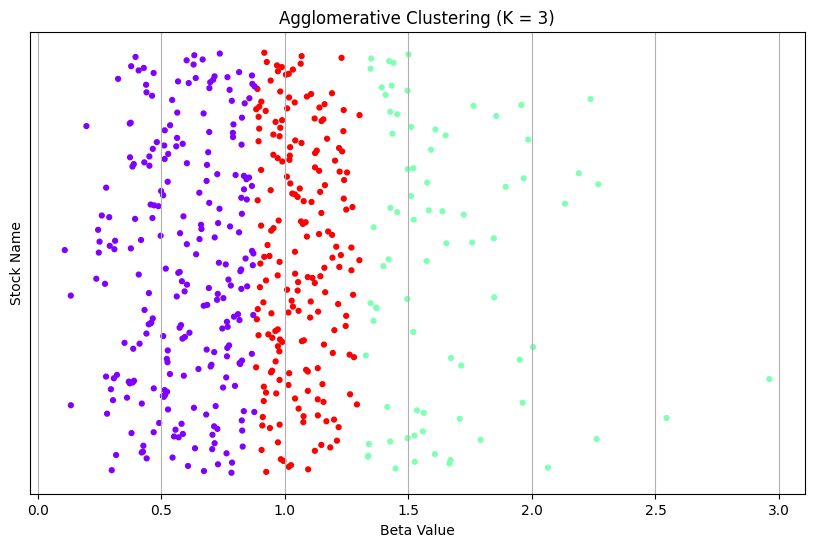

Cluster 1 has 234 observations
Cluster 2 has 77 observations
Cluster 3 has 188 observations




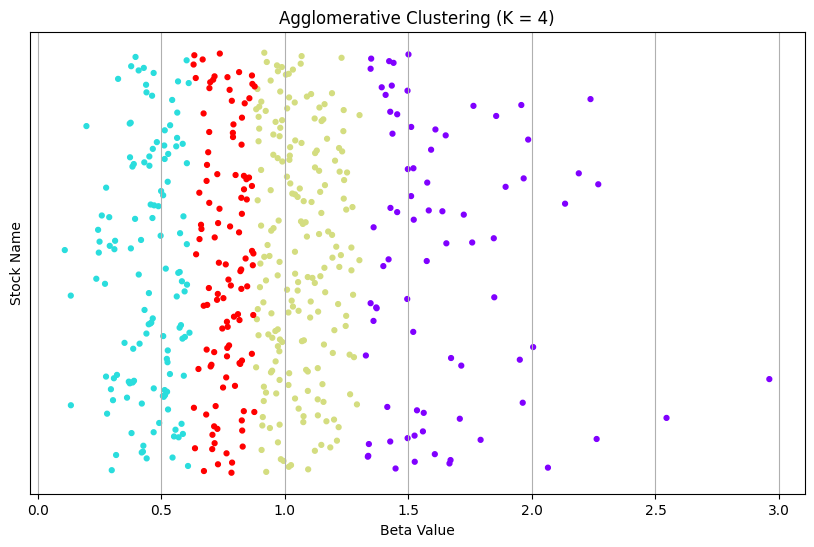

Cluster 1 has 77 observations
Cluster 2 has 126 observations
Cluster 3 has 188 observations
Cluster 4 has 108 observations




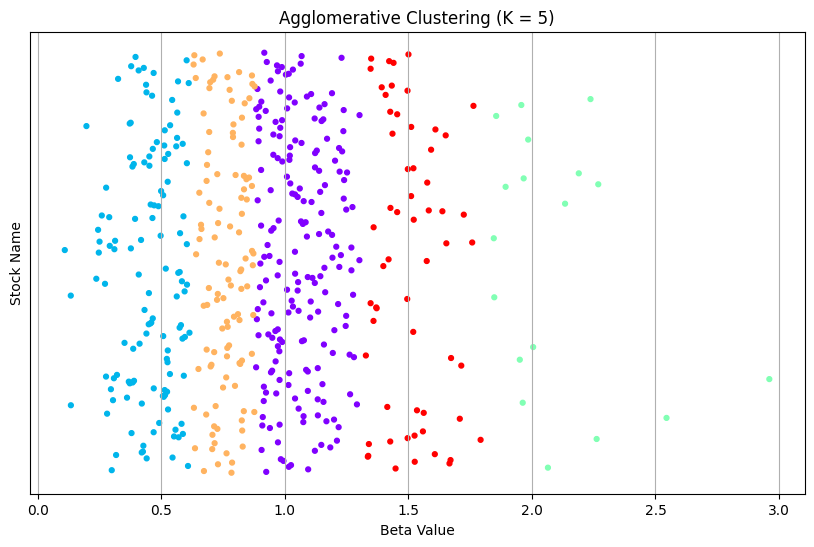

Cluster 1 has 188 observations
Cluster 2 has 126 observations
Cluster 3 has 18 observations
Cluster 4 has 108 observations
Cluster 5 has 59 observations




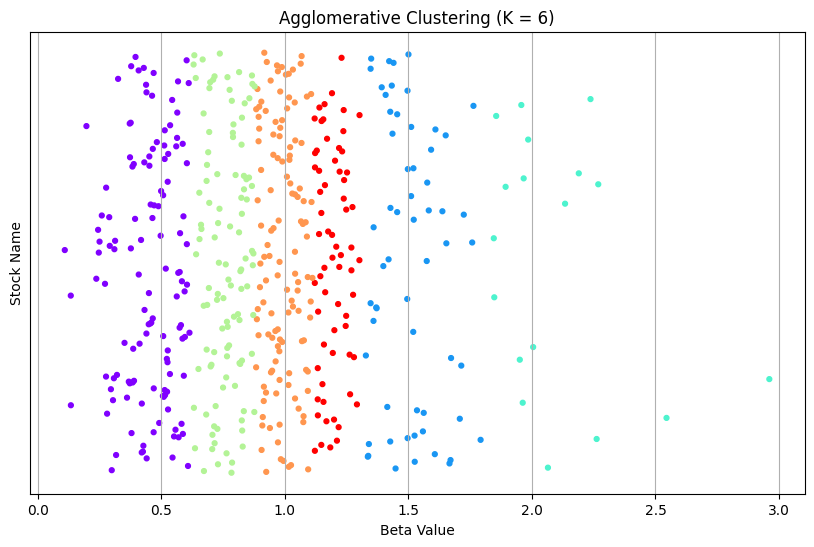

Cluster 1 has 126 observations
Cluster 2 has 59 observations
Cluster 3 has 18 observations
Cluster 4 has 108 observations
Cluster 5 has 123 observations
Cluster 6 has 65 observations




,Stock_Name,Beta,Cluster
0,MMM,0.783736,3
1,AOS,0.924451,2
2,ABT,0.672317,3
3,ABBV,0.299098,1
4,ACN,1.094208,2


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage  # for dendrogram

# 1. Load the clean betas dataframe
clean_betas_df = betas_df.dropna(subset=['Beta']).copy()

# Extract Beta values
X = clean_betas_df[['Beta']].values

# ------------------------------------------
# Optional: Dendrogram to visualize hierarchical clustering
# ------------------------------------------
linked = linkage(X, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked,
           labels=clean_betas_df['Stock_Name'].values,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=False)  # hide leaf labels if too cluttered
plt.title('Dendrogram of S&P 500 Stocks by Beta')
plt.xlabel('Stocks')
plt.ylabel('Euclidean Distance')
plt.xticks([])  # hide x-axis labels for readability
plt.show()

# 2. Test range of clusters for silhouette score (optional)
range_n_clusters = range(2, 10)
silhouette_scores = []

for n_clusters in range_n_clusters:
    model = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)
    print(f"K={n_clusters} → Silhouette Score = {score:.4f}")

# Plot silhouette scores
plt.figure(figsize=(8,5))
plt.plot(range_n_clusters, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Agglomerative Clustering')
plt.grid(True)
plt.show()

# 3. Plot clustering results for K = 3 to 6 and show counts
for K in [3, 4, 5, 6]:
    model = AgglomerativeClustering(n_clusters=K, linkage='ward')
    labels = model.fit_predict(X)
    clean_betas_df['Cluster'] = labels

    plt.figure(figsize=(10,6))
    plt.scatter(clean_betas_df['Beta'], clean_betas_df['Stock_Name'],
                c=labels, cmap='rainbow', s=12)
    plt.xlabel("Beta Value")
    plt.ylabel("Stock Name")
    plt.title(f"Agglomerative Clustering (K = {K})")
    plt.yticks([])  # hides stock names for clarity
    plt.grid(True)
    plt.show()

    # Show cluster counts
    cluster_counts = np.bincount(labels)
    for i, count in enumerate(cluster_counts):
        print(f"Cluster {i+1} has {count} observations")
    print("\n")

# 4. Optional: final clustered table for the best K (e.g., K=4)
best_K = 4
final_model = AgglomerativeClustering(n_clusters=best_K, linkage='ward')
clean_betas_df['Cluster'] = final_model.fit_predict(X)

clean_betas_df.head()


/tmp/ipython-input-25546952.py:17: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(r.text)
/tmp/ipython-input-25546952.py:34: FutureWarning: YF.download() has changed argument auto_adjust default to True
  Data_stock_price = yf.download(tickers, start=start, end=end)
[*********************100%***********************]  501 of 501 completed
/tmp/ipython-input-25546952.py:38: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  Data_stock_price_clean = Data_stock_price_clean.fillna(method='ffill')
/tmp/ipython-input-25546952.py:47: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market_data = yf.download('^GSPC', start='2022-01-01', end='2025-01-01')['Close']
[*********************100%***********************]  1 of 1 completed


Cluster Profiles (Beta & Annual Volatility):
             Beta                     Annual_Volatility                      \
             mean       min       max              mean       min       max   
Cluster                                                                       
0        0.705697  0.282267  1.161249          0.236025  0.154538  0.340460   
1        1.108193  0.143135  1.997220          0.350225  0.252585  0.592180   
2        2.110551  0.297636  3.431614          0.564378  0.403108  1.119658   
3        0.170499 -0.561384  0.539933          0.196092  0.131775  0.309902   

        Count  
        count  
Cluster        
0         203  
1         142  
2          32  
3         124  


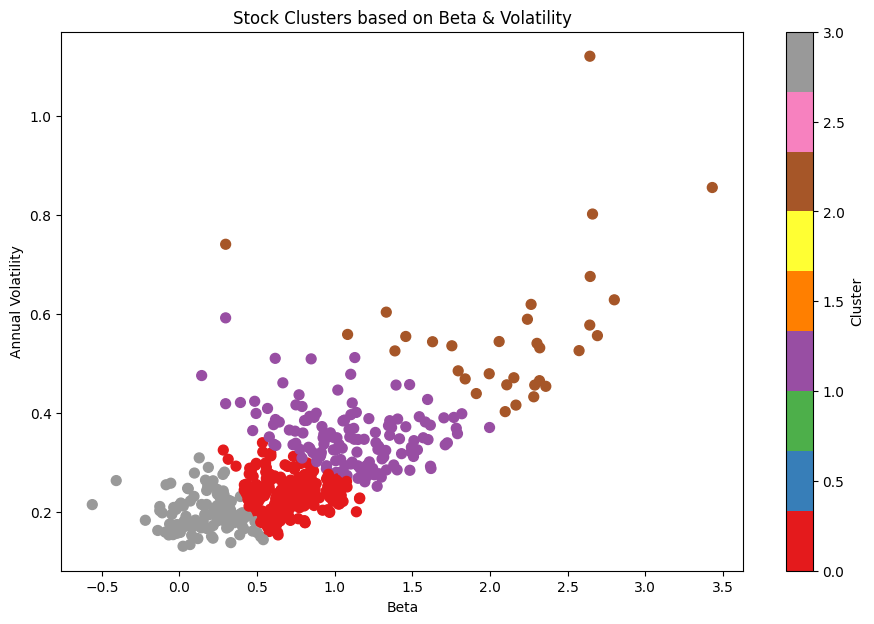

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import requests

# --- 1. Ensure cleaned stock price data is available ---
# The following code is added to ensure Data_stock_price_clean is defined.

# Get S&P 500 tickers from Wikipedia
sp500_url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
header = {"User-Agent": "Mozilla/5.0"}
r = requests.get(sp500_url, headers=header)

tables = pd.read_html(r.text)
data_table = None
for table in tables:
    if 'Symbol' in table.columns:
        data_table = table
        break

# Fix ticker symbols for Yahoo Finance
tickers = data_table["Symbol"].str.replace(".", "-", regex=False).tolist()

# Remove invalid/delisted tickers (as identified in previous runs)
invalid_tickers = ['SOLS', 'Q']
tickers = [t for t in tickers if t not in invalid_tickers]

# Download stock price data
start = '2022-01-01'
end = '2025-01-01'
Data_stock_price = yf.download(tickers, start=start, end=end)

# Clean Data_stock_price (from cell 7SBGUoXZfz5o)
Data_stock_price_clean = Data_stock_price.dropna(axis=1, how='all')
Data_stock_price_clean = Data_stock_price_clean.fillna(method='ffill')

# --- 2. Compute daily returns ---
daily_returns = Data_stock_price_clean['Close'].pct_change().dropna()

# --- 3. Compute annual volatility ---
annual_volatility = daily_returns.std() * np.sqrt(252)

# --- 4. Compute Beta relative to S&P 500 (^GSPC) ---
market_data = yf.download('^GSPC', start='2022-01-01', end='2025-01-01')['Close']
market_returns = market_data.pct_change().dropna()

beta_values = {}
for stock in daily_returns.columns:
    # Ensure market_returns and daily_returns[stock] are aligned by index
    common_index = daily_returns[stock].index.intersection(market_returns.index)
    if len(common_index) > 1:
        # Ensure both inputs to np.cov are 1-D arrays (Series)
        stock_returns_aligned = daily_returns[stock].loc[common_index]
        market_returns_aligned = market_returns.loc[common_index]['^GSPC'] # Select the Series from DataFrame

        covariance = np.cov(stock_returns_aligned, market_returns_aligned)[0, 1]
        beta = covariance / market_returns_aligned.var()
        beta_values[stock] = beta
    else:
        beta_values[stock] = np.nan # Assign NaN if not enough common data

# --- 5. Combine metrics into a DataFrame ---
stock_metrics = pd.DataFrame({
    'Beta': pd.Series(beta_values),
    'Annual_Volatility': annual_volatility
}).dropna()

# --- 6. Standardize features for K-Means ---
scaler = StandardScaler()
stock_metrics_scaled = scaler.fit_transform(stock_metrics)

# --- 7. Determine K (optional: can use Elbow/Silhouette elsewhere) ---
# For simplicity, let's assume K=4 (you can adjust after plotting elbow/silhouette)
K = 4

# --- 8. Apply K-Means clustering ---
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
stock_metrics['Cluster'] = kmeans.fit_predict(stock_metrics_scaled)

# --- 9. Analyze cluster profiles ---
cluster_summary = stock_metrics.groupby('Cluster').agg({
    'Beta': ['mean', 'min', 'max'],
    'Annual_Volatility': ['mean', 'min', 'max'],
    'Cluster': 'count'
}).rename(columns={'Cluster': 'Count'})

print("Cluster Profiles (Beta & Annual Volatility):")
print(cluster_summary)

# --- 10. Optional: Visualize clusters ---
plt.figure(figsize=(11, 7))
plt.scatter(stock_metrics['Beta'], stock_metrics['Annual_Volatility'],
            c=stock_metrics['Cluster'], cmap='Set1', s=50)
plt.xlabel('Beta')
plt.ylabel('Annual Volatility')
plt.title('Stock Clusters based on Beta & Volatility')
plt.colorbar(label='Cluster')
plt.show()

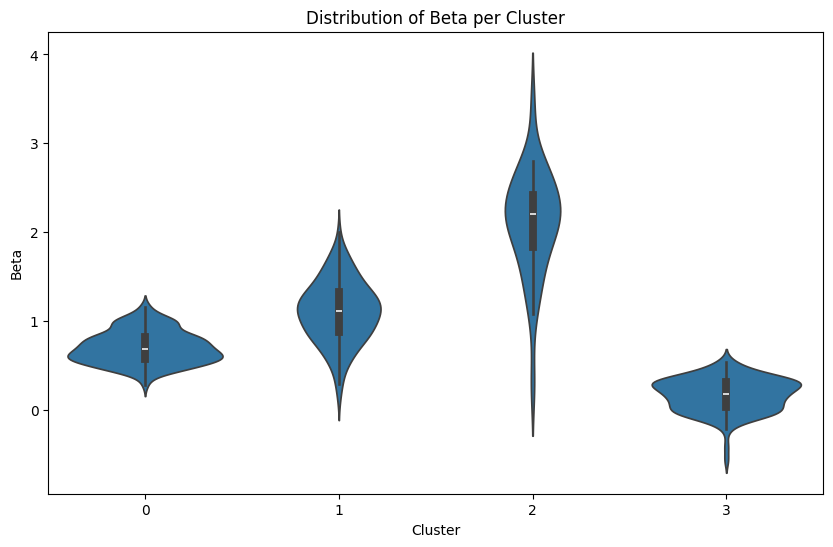

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Cluster', y='Beta', data=stock_metrics)
plt.title('Distribution of Beta per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Beta')
plt.show()


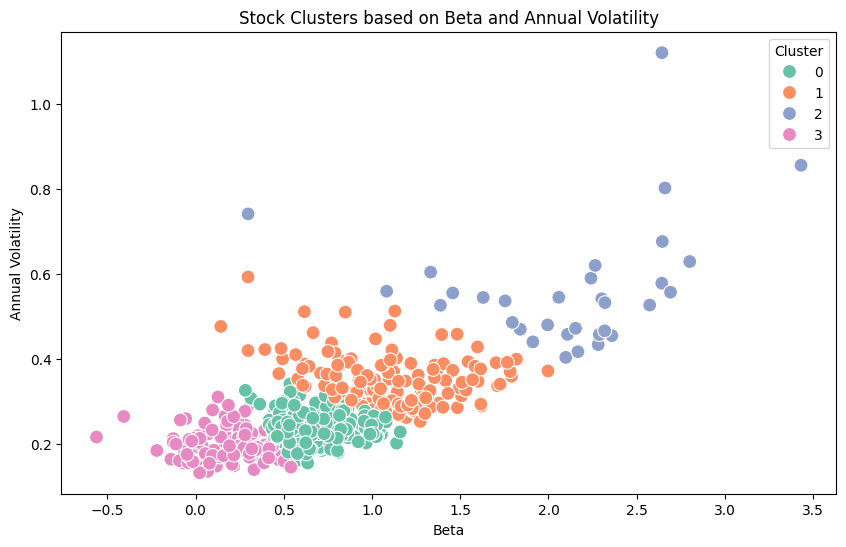

/tmp/ipython-input-1816163946.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=stock_metrics, x='Cluster', y='Annual_Volatility', palette='Set3')


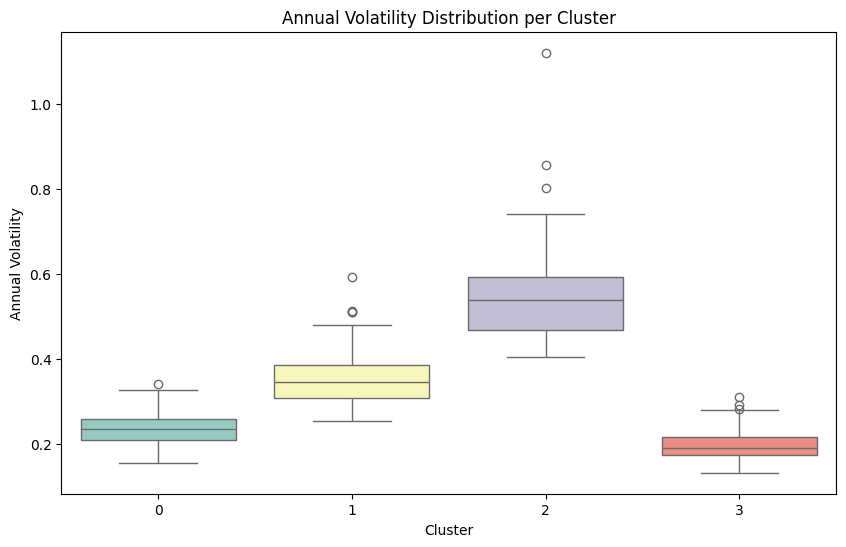

/tmp/ipython-input-1816163946.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=stock_metrics, x='Cluster', y='Beta', palette='Set3')


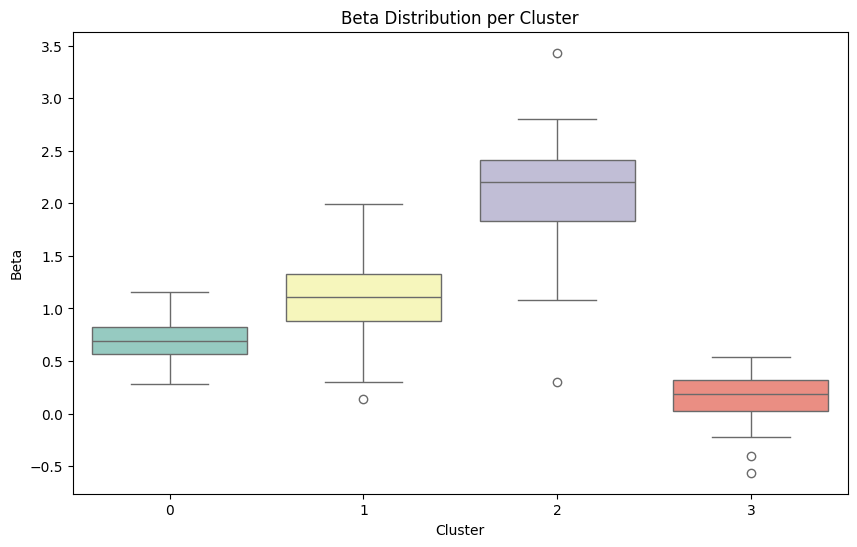

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'stock_metrics' contains Beta and Annual Volatility
# and 'kmeans_labels' contains the cluster labels from KMeans

# Add cluster labels to stock_metrics
# stock_metrics['Cluster'] = kmeans_labels # This line is removed as 'Cluster' is already in stock_metrics

# 1. Scatter plot of Beta vs Annual Volatility colored by cluster
plt.figure(figsize=(10,6))
sns.scatterplot(data=stock_metrics, x='Beta', y='Annual_Volatility', hue='Cluster', palette='Set2', s=100)
plt.title('Stock Clusters based on Beta and Annual Volatility')
plt.xlabel('Beta')
plt.ylabel('Annual Volatility')
plt.legend(title='Cluster')
plt.show()

# 2. Boxplots of Annual Volatility by cluster
plt.figure(figsize=(10,6))
sns.boxplot(data=stock_metrics, x='Cluster', y='Annual_Volatility', palette='Set3')
plt.title('Annual Volatility Distribution per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Annual Volatility')
plt.show()

# 3. Boxplots of Beta by cluster
plt.figure(figsize=(10,6))
sns.boxplot(data=stock_metrics, x='Cluster', y='Beta', palette='Set3')
plt.title('Beta Distribution per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Beta')
plt.show()